In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../')

from codes.Quantum import *
from codes.CSPSA import *

In [19]:
from scipy.linalg import sqrtm 
from scipy.linalg import inv 

def complex2unitary( Z ):
    if Z.ndim == 3:
        for k, z in enumerate(Z):
            Z[k] = z @ inv( sqrtm( z.T.conj()@z ) )
    else:
        Z = Z @ inv( sqrtm( Z.T.conj()@Z ) )
    return Z 

def random_unitary( dim, num=1 ):
    Z = np.random.randn( num, dim, dim ) \
        + 1j*np.random.randn( num, dim, dim )
    return complex2unitary( Z ).squeeze()

def postprocessing(U):
    # U, _ = np.linalg.qr(U)
    # # U = U@(U.T.conj()U).
    return complex2unitary( U )

In [20]:
def trineq(Us, Rho ):

    Us = np.array(Us)
    Us = postprocessing(Us)

    M_per_system = []
    for U in Us:
        M_each_qubit = []
        for u in U:
            M_each_qubit.append( np.outer(u,u.conj()) )
        M_per_system.append( M_each_qubit )
    probs = InnerProductMatrices( Rho, M_per_system ).real
    probs = probs.reshape(6*[2]) 

    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )

    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1]*probs_clcr[1,0] 
                -probs_clcr[0,0]*probs_clcr[1,1] 
                -probs_clcr[0,1]*probs[1,0,0,1,1,0]
                -probs_clcr[0,1]*probs[1,1,0,0,1,0]
                +probs_clcr[0,0]*probs[1,0,1,1,1,1]
                +probs_clcr[0,0]*probs[1,1,1,0,1,1]
                +probs_clcr[1,0]*probs[0,0,1,0,0,1]
                +probs_clcr[1,0]*probs[0,1,1,1,0,1]
                +probs_clcr[1,1]*probs[0,0,0,0,0,0]
                +probs_clcr[1,1]*probs[0,1,0,1,0,0]
                )
    
    return inequality

In [21]:
M = np.zeros( (2,2,2,2) )

M[0,1,:,:] = np.array([  [1, 0], [0, 1]  ]) #Z
M[0,0,:,:] = np.array([  [1, 1], [1, -1]  ])/np.sqrt(2) #X

M[1,0,0,:] = np.array([1-np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) )  #X+Z
M[1,0,1,:] = np.array([1+np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )

M[1,1,0,:] = np.array([-1-np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )
M[1,1,1,:] = np.array([-1+np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) ) #

Comp_basis = np.eye(2) 

vec_alice = np.zeros( (2,2,4) )
for l in range(2):
    for k in range(2):
        vec_alice[l,k,:]  = np.kron( Comp_basis[l], M[0,l,k,:] )
vec_alice = vec_alice.reshape(4,4)

vec_bob = np.zeros( (2,2,4) )
for m in range(2):
    for kk in range(2):
        vec_bob[m,kk,:] = np.kron( Comp_basis[m], M[1,m,kk,:] )
vec_bob = vec_bob.reshape(4,4)

Comp_basis = np.array([ 0,1,1,0 ]).reshape(2,2)
vec_charlie = np.zeros( (2,2,4) )
for i in range(2):
    for j in range(2):
        vec_charlie[i,j,:] = np.kron( Comp_basis[i], Comp_basis[j] )
vec_charlie = vec_charlie.reshape(4,4)

psi = np.array([ 0, 1, -1, 0 ])/np.sqrt(2)
a = 0.95
rho = a*np.outer( psi,psi.conj())+(1-a)*np.eye(4)/4 
Rho = triple_kron( rho, rho, rho ) 
Rho = Rho.reshape(2*6*[2]).transpose(
        [ 5,0,2,1,4,3, 11,6,8,7,10,9]).reshape([ 2**6, 2**6 ])
# [ 10,0,4,2,8,6, 11,1,5,3,9,7 ]
# |i1><i2|X|j1><j2| ---> |i1>|j1><i2|<j2| 
# 

# Psi_ab = np.array([ 0, 1, -1, 0 ])/np.sqrt(2)
# Psi = triple_kron( Psi_ab, Psi_ab, Psi_ab )
# Psi = Psi.reshape(6*[2]).transpose([5,0,2,1,4,3]).flatten() 
# Rho = np.outer( Psi, Psi.conj() )

trineq( np.array([vec_alice, vec_bob, vec_charlie]), Rho ), (np.sqrt(2)-1)/16 

(0.001893276834023544, 0.025888347648318447)

In [22]:
gains = [3, 0, 0.1, 0.602, 0.101]
max_iter = 500
max_rep = 10
Out = []
iter = np.linspace(0.0, 0.5, 6)
aas = np.linspace(0.9,1,6)

Out = np.empty((max_rep, max_iter))

for i in range(6):
    a = aas[i]
    ####
    psi = np.array([ 0, 1, -1, 0 ])/np.sqrt(2)
    rho = a* np.outer( psi,psi.conj())+(1-a)*np.eye(4)/4 
    Rho = triple_kron( rho, rho, rho )
    Rho = Rho.reshape(2*6*[2]).transpose(
            [ 5,0,2,1,4,3, 11,6,8,7,10,9 ]).reshape(2**6,2**6)
    ####
    print( a, rho )
    for k in range(max_rep):

        Us_in = np.array([ np.kron(random_unitary(2), 
                                   random_unitary(2)) for _ in range(3) ]) 

        cspsa = CSPSA(gains=gains, minimize=False)
        
        results = cspsa.minimize(trineq, 
                                 Us_in, 
                                 max_iter, 
                                 args = (Rho), 
                                 postprocessing=postprocessing )
        infidelities = results.fun

        Out[k, :] = infidelities
    
    np.save("Data_sim_0"+str(i), Out)

0.9 [[ 0.025  0.     0.     0.   ]
 [ 0.     0.475 -0.45   0.   ]
 [ 0.    -0.45   0.475  0.   ]
 [ 0.     0.     0.     0.025]]
0.92 [[ 0.02  0.    0.    0.  ]
 [ 0.    0.48 -0.46  0.  ]
 [ 0.   -0.46  0.48  0.  ]
 [ 0.    0.    0.    0.02]]
0.9400000000000001 [[ 0.015  0.     0.     0.   ]
 [ 0.     0.485 -0.47   0.   ]
 [ 0.    -0.47   0.485  0.   ]
 [ 0.     0.     0.     0.015]]
0.96 [[ 0.01  0.    0.    0.  ]
 [ 0.    0.49 -0.48  0.  ]
 [ 0.   -0.48  0.49  0.  ]
 [ 0.    0.    0.    0.01]]
0.98 [[ 0.005  0.     0.     0.   ]
 [ 0.     0.495 -0.49   0.   ]
 [ 0.    -0.49   0.495  0.   ]
 [ 0.     0.     0.     0.005]]
1.0 [[ 0.   0.   0.   0. ]
 [ 0.   0.5 -0.5  0. ]
 [ 0.  -0.5  0.5  0. ]
 [ 0.   0.   0.   0. ]]


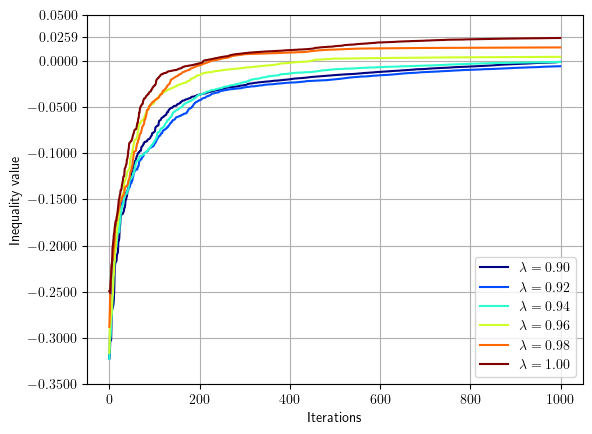

In [25]:
plt.figure()
n = 6
colors = plt.cm.jet(np.linspace(0,1,n))

# If this cell runs before the one that defines these, provide safe defaults
if 'aas' not in globals():
    aas = np.linspace(0.9, 1, 6)
if 'max_iter' not in globals():
    max_iter = 500

for i in range(6):
    Load = "Data_sim_0"+str(i)+".npy"
    Data = np.load(Load)

    Data_median = np.median(Data, axis=0)
    Label = r'$\lambda = {:.2f}$'.format(aas[i])
    plt.plot(Data_median, color=colors[i], label=Label)
    plt.legend()
    plt.savefig("t0"+str(i)+".png")



nuevo_tick = 0.02588

# Obtener el eje actual
ax = plt.gca()

# Obtener ticks actuales del eje Y
yticks = ax.get_yticks()

# Agregar el nuevo tick
yticks = np.sort(np.append(yticks, nuevo_tick))

# Fijar los ticks
ax.set_yticks(yticks)

#plt.hlines(0, 0, 1000, linestyles='--')

plt.grid()
plt.xlabel(r"Iterations")
plt.ylabel(r"Inequality value")
#plt.hlines((np.sqrt(2)-1)/16, 0, 1000, linestyles='--')
plt.savefig("werner.pdf")